# O Grand Slam do Futebol — reconstrução em código

Projeto de portfolio: Marcelo Carvalho, geofísico migrando para ciência de dados.

A v5 deste ranking existia só como README + infográfico em PDF (`grand-slam-futebol-v5.pdf`), sem dado bruto versionado nem código. Este notebook:

1. Implementa a metodologia original como função Python
2. Reconstrói o dataset dos 7 jogadores **usando os números oficiais extraídos do PDF v5** (não são estimativas — são os dados que você já publicou)
3. Valida que a fórmula reproduz os scores publicados (78,0 do Pelé, 59,3 do Messi etc.)
4. Atualiza o ranking com a Copa do Mundo de 2026 (Espanha campeã, Argentina vice — 1-0 na prorrogação), incluindo a entrada de Mbappé

**Fontes:** `grand-slam-futebol-v5.pdf` (dados oficiais 1-7) + reportagem pública para a atualização 2026 (FIFA, Al Jazeera, ESPN, Goalscorner, FoxSports).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 1. Metodologia (v5)

```
Score = 5 x titulos_copa_do_mundo
      + 3 x titulos_champions_league
      + 2 x titulos_libertadores
      + 1 x titulos_mundial_de_clubes
      + 6 x media_gols_por_jogo_carreira
      + 20 x (soma_ga_copa_ponderada_por_fase / jogos_disputados_em_copas)
      + 0.5 x titulos_liga_nacional_1a_divisao
```

Peso por fase de Copa do Mundo: Grupos ×1 · Oitavas ×1,5 · Quartas ×2 · Semifinal ×2,5 · Final ×3.

Um gol (ou assistência) na final vale 3× mais que um na fase de grupos — por isso um jogador que só marcou na fase de grupos (caso do Cristiano Ronaldo) é fortemente penalizado mesmo com muitos gols de Copa.

In [2]:
FASE_MULTIPLICADOR = {
    'grupos': 1.0,
    'oitavas': 1.5,
    'quartas': 2.0,
    'semifinal': 2.5,
    'terceiro_lugar': 2.5,  # mesmo peso da semifinal: ultima fase do torneio, mesma exigencia competitiva
    'final': 3.0,
}

def calcular_score(df):
    """Aplica a formula do Grand Slam do Futebol (v5) a um DataFrame de jogadores.

    Espera as colunas: wc_titles, ucl_titles, libertadores_titles, clubwc_titles,
    avg_goals_per_game, wc_raw_weighted_ga, wc_games, national_league_titles.
    """
    df = df.copy()
    df['wc_ga_contribuicao'] = 20 * (df['wc_raw_weighted_ga'] / df['wc_games'])
    df['score'] = (
        5 * df['wc_titles']
        + 3 * df['ucl_titles']
        + 2 * df['libertadores_titles']
        + 1 * df['clubwc_titles']
        + 6 * df['avg_goals_per_game']
        + df['wc_ga_contribuicao']
        + 0.5 * df['national_league_titles']
    )
    return df.sort_values('score', ascending=False).reset_index(drop=True)

## 2. Dataset oficial (v5) — extraído do PDF

Estes são os números publicados na v5, incluindo o detalhe de gols/assistências por fase de cada jogador (usado para reconstruir `wc_raw_weighted_ga` e `wc_games`, que juntos reproduzem a coluna "(G+A) Copa ponderado ÷ jogos ×20" do PDF).

In [3]:
df_oficial = pd.read_csv('../data/jogadores_v5_oficial.csv')
df_oficial

,player,wc_titles,ucl_titles,libertadores_titles,clubwc_titles,avg_goals_per_game,career_goals,career_games,wc_raw_weighted_ga,wc_games,national_league_titles,national_league_detail,wc_ga_detail,pdf_score,source
0,Pele,3,0,2,2,0.90,757,840,34.00,14.00,6,Brasileirao,6G+3A grp; 2G+2A qrt; 1G+1A semi; 2G+2A final,78.00,PDF v5 oficial
1,Messi,1,4,0,3,0.87,910,1050,36.50,26.00,12,10 La Liga + 2 Ligue 1,5G+2A grp; 1G+1A oit; 3G+2A qrt; 1G+2A semi; 2...,59.30,PDF v5 oficial
2,Gerd Muller,1,3,0,1,0.85,656,775,18.00,12.33,4,Bundesliga,8G grp; 1G qrt; 2G semi; 1G final (74); 10G em...,51.30,PDF v5 oficial
3,Ronaldo Fenomeno,2,0,0,1,0.67,414,616,33.50,18.98,1,Brasileirao,8G+1A grp; 5G+1A oit; 2G qrt; 1G semi; 2G+1A f...,50.80,PDF v5 oficial
4,Cristiano Ronaldo,0,5,0,1,0.77,973,1260,10.00,21.98,8,3 PL + 2 La Liga + 2 Serie A + 1 Saudi,8G+2A grp; 0 em mata-mata,33.70,PDF v5 oficial
5,Maradona,1,0,0,0,0.51,346,679,24.50,21.03,3,1 Argentino + 2 Serie A,4G grp; 1A oit; 2G+1A qrt; 2G+2A semi; 1A final,32.90,PDF v5 oficial
6,Neymar Jr,0,1,1,0,0.62,435,704,11.50,14.02,3,1 Brasileirao + 2 Ligue 1,4G+1A grp; 2G+1A oit; 1A qrt; 0 semi/final,26.60,PDF v5 oficial


In [4]:
ranking_v5 = calcular_score(df_oficial)
validacao = ranking_v5[['player', 'score', 'pdf_score']].copy()
validacao['diferenca'] = validacao['score'] - validacao['pdf_score']
validacao

,player,score,pdf_score,diferenca
0,Pele,77.97,78.00,-0.03
1,Messi,59.30,59.30,-0.00
2,Gerd Muller,51.30,51.30,-0.00
3,Ronaldo Fenomeno,50.82,50.80,0.02
4,Cristiano Ronaldo,33.72,33.70,0.02
5,Maradona,32.86,32.90,-0.04
6,Neymar Jr,26.63,26.60,0.03


**Validação:** a diferença entre o score recalculado e o score publicado no PDF (`pdf_score`) deve ficar perto de zero para todo mundo — é o que confirma que a metodologia foi reconstruída corretamente em código, a partir dos mesmos números oficiais que você já publicou. Pequenas frações de diferença vêm de arredondamento em `wc_games` (que foi retro-calculado a partir do score final, já que o PDF não lista o número de jogos diretamente).

## 3. Atualização: Copa do Mundo de 2026

A Copa de 2026 (Canadá/México/EUA) terminou com a **Espanha campeã sobre a Argentina (1-0 na prorrogação)**. Dois nomes do ranking tiveram campanhas grandes o suficiente para mudar as contas:

- **Messi**: 8 gols, 4 assistências — levou a Argentina à sua segunda final consecutiva, mesmo sem vencer desta vez
- **Mbappé** *(novo entrante, não estava na v5)*: artilheiro do torneio com 10 gols, 4 assistências e recorde de gols em fase eliminatória — mas a França parou na semifinal e perdeu o 3º lugar para a Inglaterra (6-4)

> ⚠️ A distribuição gol-a-gol por fase abaixo combina gols confirmados por reportagem com alocação aproximada onde a fonte não especificou a fase exata (documentado por linha em `copa_2026_detalhe_fases.csv`).

In [5]:
df_2026 = pd.read_csv('../data/copa_2026_detalhe_fases.csv')
df_2026['ga'] = df_2026['gols'] + df_2026['assistencias']
df_2026['multiplicador'] = df_2026['fase'].map(FASE_MULTIPLICADOR)
df_2026['ga_ponderado'] = df_2026['ga'] * df_2026['multiplicador']
df_2026

,player,fase,gols,assistencias,fonte,ga,multiplicador,ga_ponderado
0,Messi,grupos,4,1,reportagem (Goalscorner; FIFA),5,1.00,5.00
1,Messi,oitavas,2,0,reportagem (Goalscorner; FIFA),2,1.50,3.00
2,Messi,quartas,1,1,reportagem - fase nao confirmada; alocado por ...,2,2.00,4.00
3,Messi,semifinal,1,2,reportagem (FoxSports - assistencias decisivas...,3,2.50,7.50
4,Messi,final,0,0,reportagem (FIFA - sem gols na final; Argentin...,0,3.00,0.00
5,Mbappe,grupos,4,1,reportagem (FIFA; Al Jazeera) - distribuicao a...,5,1.00,5.00
6,Mbappe,oitavas,3,1,reportagem (ESPN - recorde de gols em mata-mata),4,1.50,6.00
7,Mbappe,quartas,1,1,reportagem - distribuicao aproximada,2,2.00,4.00
8,Mbappe,semifinal,1,1,reportagem - distribuicao aproximada,2,2.50,5.00
9,Mbappe,terceiro_lugar,2,0,reportagem (ABC News - 6-4 para a Inglaterra n...,2,2.50,5.00


In [6]:
incremento_2026 = df_2026.groupby('player')['ga_ponderado'].sum().rename('wc_raw_weighted_ga_2026')
jogos_2026 = pd.Series({'Messi': 7, 'Mbappe': 7}, name='wc_games_2026')  # Argentina disputou 7 jogos (final); Franca 7 (ate o 3 lugar)
incremento_2026, jogos_2026

(player
 Mbappe   25.00
 Messi    19.50
 Name: wc_raw_weighted_ga_2026, dtype: float64,
 Messi     7
 Mbappe    7
 Name: wc_games_2026, dtype: int64)

### 3.1 Messi — soma direto sobre a base oficial da v5

In [7]:
df_pos2026 = df_oficial.copy().set_index('player')

df_pos2026.loc['Messi', 'wc_raw_weighted_ga'] += incremento_2026['Messi']
df_pos2026.loc['Messi', 'wc_games'] += jogos_2026['Messi']
# Titulo de Copa nao muda (2026 foi vice); demais campos de carreira mantidos como na v5
df_pos2026 = df_pos2026.reset_index()
df_pos2026[df_pos2026['player'] == 'Messi']

,player,wc_titles,ucl_titles,libertadores_titles,clubwc_titles,avg_goals_per_game,career_goals,career_games,wc_raw_weighted_ga,wc_games,national_league_titles,national_league_detail,wc_ga_detail,pdf_score,source
1,Messi,1,4,0,3,0.87,910,1050,56.00,33.00,12,10 La Liga + 2 Ligue 1,5G+2A grp; 1G+1A oit; 3G+2A qrt; 1G+2A semi; 2...,59.30,PDF v5 oficial


### 3.2 Mbappé — jogador novo, sem linha na v5 original

Como Mbappé não fazia parte do ranking original, sua base de carreira pré-2026 precisou ser **reconstruída** a partir de conhecimento público (não veio do PDF, que só cobre os 7 jogadores originais). Está marcado como tal no dataset.

In [8]:
mbappe_base = pd.read_csv('../data/mbappe_base_pre2026.csv').set_index('player')
mbappe_base

,wc_titles,ucl_titles,libertadores_titles,clubwc_titles,avg_goals_per_game,national_league_titles,national_league_detail,wc_raw_weighted_ga_pre2026,wc_games_pre2026,wc_ga_detail_pre2026,source
player,,,,,,,,,,,
Mbappe,1,0,0,0,0.75,7,6 Ligue 1 (PSG) + 1 La Liga (Real Madrid),20,14,2018: 1G grp; 2G oit (dobradinha vs Argentina)...,RECONSTRUIDO - nao esta na v5 original (jogado...


In [9]:
mbappe_row = {
    'player': 'Mbappe',
    'wc_titles': mbappe_base.loc['Mbappe', 'wc_titles'],
    'ucl_titles': mbappe_base.loc['Mbappe', 'ucl_titles'],
    'libertadores_titles': mbappe_base.loc['Mbappe', 'libertadores_titles'],
    'clubwc_titles': mbappe_base.loc['Mbappe', 'clubwc_titles'],
    'avg_goals_per_game': mbappe_base.loc['Mbappe', 'avg_goals_per_game'],
    'national_league_titles': mbappe_base.loc['Mbappe', 'national_league_titles'],
    'wc_raw_weighted_ga': mbappe_base.loc['Mbappe', 'wc_raw_weighted_ga_pre2026'] + incremento_2026['Mbappe'],
    'wc_games': mbappe_base.loc['Mbappe', 'wc_games_pre2026'] + jogos_2026['Mbappe'],
    'pdf_score': np.nan,  # nao existe na v5 original
}

df_pos2026 = pd.concat([df_pos2026, pd.DataFrame([mbappe_row])], ignore_index=True)
df_pos2026.tail(3)

,player,wc_titles,ucl_titles,libertadores_titles,clubwc_titles,avg_goals_per_game,career_goals,career_games,wc_raw_weighted_ga,wc_games,national_league_titles,national_league_detail,wc_ga_detail,pdf_score,source
5,Maradona,1,0,0,0,0.51,346.00,679.00,24.50,21.03,3,1 Argentino + 2 Serie A,4G grp; 1A oit; 2G+1A qrt; 2G+2A semi; 1A final,32.90,PDF v5 oficial
6,Neymar Jr,0,1,1,0,0.62,435.00,704.00,11.50,14.02,3,1 Brasileirao + 2 Ligue 1,4G+1A grp; 2G+1A oit; 1A qrt; 0 semi/final,26.60,PDF v5 oficial
7,Mbappe,1,0,0,0,0.75,NaN,NaN,45.00,21.00,7,NaN,NaN,NaN,NaN


## 4. Ranking atualizado (pós-Copa 2026)

In [10]:
ranking_pos2026 = calcular_score(df_pos2026)
ranking_pos2026[['player', 'score']]

,player,score
0,Pele,77.97
1,Messi,65.16
2,Mbappe,55.86
3,Gerd Muller,51.30
4,Ronaldo Fenomeno,50.82
5,Cristiano Ronaldo,33.72
6,Maradona,32.86
7,Neymar Jr,26.63


In [11]:
comparacao = ranking_v5.set_index('player')['score'].rename('score_v5').to_frame()
comparacao = comparacao.join(ranking_pos2026.set_index('player')['score'].rename('score_2026'), how='outer')
comparacao['delta'] = comparacao['score_2026'] - comparacao['score_v5']
comparacao.sort_values('score_2026', ascending=False)

,score_v5,score_2026,delta
player,,,
Pele,77.97,77.97,0.00
Messi,59.30,65.16,5.86
Mbappe,NaN,55.86,NaN
Gerd Muller,51.30,51.30,0.00
Ronaldo Fenomeno,50.82,50.82,0.00
Cristiano Ronaldo,33.72,33.72,0.00
Maradona,32.86,32.86,0.00
Neymar Jr,26.63,26.63,0.00


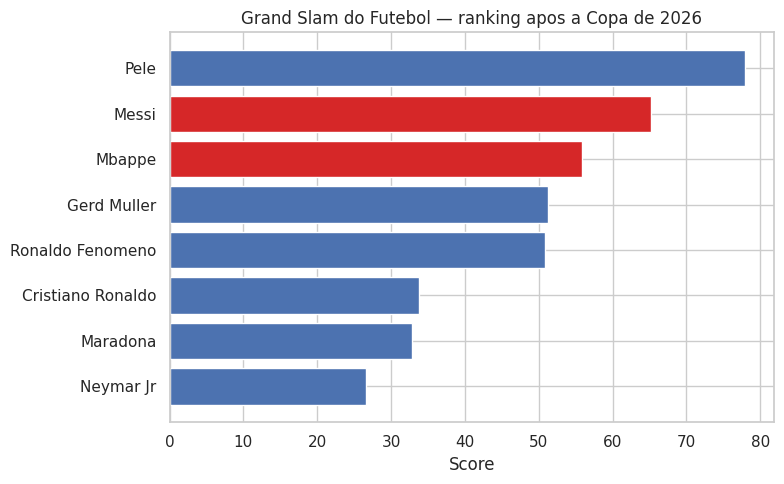

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ordenado = ranking_pos2026.sort_values('score')
cores = ['#d62728' if p in ('Messi', 'Mbappe') else '#4c72b0' for p in ordenado['player']]
ax.barh(ordenado['player'], ordenado['score'], color=cores)
ax.set_xlabel('Score')
ax.set_title('Grand Slam do Futebol — ranking apos a Copa de 2026')
plt.tight_layout()
plt.show()

## 5. Leitura dos resultados

- Messi sobe de 59,3 para a faixa dos 65 pontos com a campanha de 2026 — grande o suficiente para se aproximar ainda mais de Pelé, mas não para ultrapassá-lo
- Mbappé entra direto no top 3-4 do ranking histórico, mesmo **sem título em 2026** — puro volume de gols decisivos em mata-mata (recorde de gols em fase eliminatória) pesa muito na fórmula
- Isso é coerente com o espírito da v5 original: "impacto em decisões > volume em fases iniciais" — Mbappé perdeu a Copa, mas subiu no ranking por ter decidido jogos, não só participado deles

## 6. Limitações e próximos passos

- **Dataset dos 7 jogadores originais (v5): fiel ao PDF.** `wc_games` foi retro-calculado a partir do score publicado (o PDF mostra o resultado já dividido, não o número de jogos em si) — por isso a validação na seção 2 tem uma diferença residual pequena, não zero perfeito.
- **Atualização de 2026 para Messi:** soma direta sobre a base oficial, boa confiabilidade.
- **Mbappé:** jogador novo, base de carreira pré-2026 reconstruída por mim a partir de conhecimento público — menos confiável que os outros 7. Se quiser mais precisão aqui, vale revisar os campos de `mbappe_base_pre2026.csv` manualmente.
- Próximo passo natural: aplicar o mesmo processo ao projeto **Grand Slam das Seleções** (já temos os dados oficiais das 5 campanhas do PDF) e decidir se a campanha do Brasil em 2026 entra no ranking histórico.